In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Critical: Set multiprocessing start method for Windows compatibility
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


In [3]:
DATASET_PATH = Path("./herbal_domain_dataset")
source_df = pd.read_csv(DATASET_PATH / "source" / "labels.csv")
test_df = pd.read_csv(DATASET_PATH / "test" / "test_labels.csv")

source_img_paths = [DATASET_PATH / "source" / "images" / f for f in source_df['filename']]
source_labels = source_df['species_id'].values

test_img_paths = [DATASET_PATH / "test" / "images" / f for f in test_df['filename']]
test_labels = test_df['species_id'].values

num_classes = len(source_df['species'].unique())
print(f"Source: {len(source_img_paths)} images, {num_classes} classes")
print(f"Test: {len(test_img_paths)} images")

Source: 514 images, 18 classes
Test: 104 images


In [4]:
class HerbalDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.img_paths)
    
    def __getitem__(self, idx):
        img = cv2.imread(str(self.img_paths[idx]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [6]:
#  Transforms
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Split into train/val
train_size = int(0.8 * len(source_img_paths))
val_size = len(source_img_paths) - train_size

full_dataset = HerbalDataset(source_img_paths, source_labels, train_transform)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Replace val dataset transform
val_dataset.dataset.transform = val_transform

test_dataset = HerbalDataset(test_img_paths, test_labels, val_transform)

#  Set num_workers=0
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Train: {train_size}, Val: {val_size}, Test: {len(test_labels)}")
print(f"Batch size: 32, Workers: 0 ")

Train: 411, Val: 103, Test: 104
Batch size: 32, Workers: 0 


In [7]:
# Training Function
def train_model(model, model_name, lr=0.001, epochs=50):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    model = model.to(device)
    best_val_acc = 0
    best_epoch = 0
    train_losses, val_accs = [], []
    patience = 10
    patience_counter = 0
    
    for epoch in range(epochs):
        # Train
        model.train()
        total_loss = 0
        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())
        
        val_acc = accuracy_score(val_true, val_preds)
        train_losses.append(total_loss / len(train_loader))
        val_accs.append(val_acc)
        scheduler.step()
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch+1) % 5 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{epochs} - Loss: {train_losses[-1]:.4f} - Val Acc: {val_acc:.4f} - LR: {current_lr:.6f}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    return train_losses, val_accs, best_val_acc, best_epoch

In [8]:
# Model 1 - Fine-tuned ResNet18
print("MODEL 1: ResNet18 with Fine-tuning")

model1 = models.resnet18(pretrained=True)
for param in model1.parameters():
    param.requires_grad = True
model1.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model1.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

train_losses1, val_accs1, best1, epoch1 = train_model(model1, "resnet18_finetuned", lr=0.0001, epochs=50)
print(f"\n Best Validation Accuracy: {best1:.4f} at epoch {epoch1}")

MODEL 1: ResNet18 with Fine-tuning


Epoch 5/50: 100%|██████████████████████████████████████████████████████████████████████| 13/13 [01:54<00:00,  8.81s/it]


Epoch 5/50 - Loss: 0.5165 - Val Acc: 0.8932 - LR: 0.000098


Epoch 10/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:59<00:00,  9.21s/it]


Epoch 10/50 - Loss: 0.0978 - Val Acc: 0.9612 - LR: 0.000090


...

Epoch 20/50 - Loss: 0.0235 - Val Acc: 0.9903 - LR: 0.000065


Epoch 25/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:59<00:00,  9.22s/it]


Epoch 25/50 - Loss: 0.0186 - Val Acc: 0.9903 - LR: 0.000050


Epoch 28/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:59<00:00,  9.20s/it]


Early stopping at epoch 28

 Best Validation Accuracy: 0.9903 at epoch 17


In [9]:
# Model 2 - Fine-tuned EfficientNet-B0
print("MODEL 2: EfficientNet-B0 with Fine-tuning")


model2 = models.efficientnet_b0(pretrained=True)
for param in model2.parameters():
    param.requires_grad = True
model2.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model2.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

train_losses2, val_accs2, best2, epoch2 = train_model(model2, "efficientnet_finetuned", lr=0.0001, epochs=50)
print(f"\n Best Validation Accuracy: {best2:.4f} at epoch {epoch2}")

MODEL 2: EfficientNet-B0 with Fine-tuning


Epoch 5/50: 100%|██████████████████████████████████████████████████████████████████████| 13/13 [02:44<00:00, 12.62s/it]


Epoch 5/50 - Loss: 1.2899 - Val Acc: 0.7573 - LR: 0.000098


Epoch 10/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:23<00:00,  6.40s/it]


Epoch 10/50 - Loss: 0.3436 - Val Acc: 0.8932 - LR: 0.000090


...

Epoch 30/50 - Loss: 0.0389 - Val Acc: 0.9903 - LR: 0.000035


Epoch 35/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:26<00:00,  6.66s/it]


Epoch 35/50 - Loss: 0.0354 - Val Acc: 0.9903 - LR: 0.000021


Epoch 38/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:24<00:00,  6.51s/it]


Early stopping at epoch 38

 Best Validation Accuracy: 0.9903 at epoch 27


In [12]:
# CELL 8: Model 3 - MobileNetV3 
print("MODEL 3: MobileNetV3 (Lightweight)")

model3 = models.mobilenet_v3_large(pretrained=True)

print("Original classifier structure:")
print(model3.classifier)

in_features = model3.classifier[3].in_features
print(f"Original classifier expects: {in_features}")

#adaptive pooling 
model3.avgpool = nn.AdaptiveAvgPool2d(1)

model3.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(960, 512),  
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

print(f"New classifier: expects 960 features -> {num_classes} classes")

# Unfreeze all layers
for param in model3.parameters():
    param.requires_grad = True

train_losses3, val_accs3, best3, epoch3 = train_model(model3, "mobilenet_finetuned", lr=0.0001, epochs=50)
print(f"\n Best Validation Accuracy: {best3:.4f} at epoch {epoch3}")

MODEL 3: MobileNetV3 (Lightweight)
Original classifier structure:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)
Original classifier expects: 1280
New classifier: expects 960 features -> 18 classes


Epoch 5/50: 100%|██████████████████████████████████████████████████████████████████████| 13/13 [01:43<00:00,  7.98s/it]


Epoch 5/50 - Loss: 1.0917 - Val Acc: 0.5922 - LR: 0.000098


Epoch 10/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:42<00:00,  7.87s/it]


Epoch 10/50 - Loss: 0.2856 - Val Acc: 0.8641 - LR: 0.000090


...

Epoch 20/50 - Loss: 0.0634 - Val Acc: 0.9806 - LR: 0.000065


Epoch 25/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:40<00:00,  7.72s/it]


Epoch 25/50 - Loss: 0.0446 - Val Acc: 0.9806 - LR: 0.000050


Epoch 29/50: 100%|█████████████████████████████████████████████████████████████████████| 13/13 [01:39<00:00,  7.66s/it]


Early stopping at epoch 29

 Best Validation Accuracy: 0.9806 at epoch 18


In [14]:
#Evaluate All Models on Test Set
print("TEST SET EVALUATION")

def evaluate_model(model, model_name, model_path):
    try:
        model.load_state_dict(torch.load(model_path))
        model.eval()
        model = model.to(device)
        
        all_preds, all_labels = [], []
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        acc = accuracy_score(all_labels, all_preds)
        return acc, all_preds
    except FileNotFoundError:
        print(f"  Model file not found: {model_path}")
        return None, None

# Evaluate all three models
models_dict = {
    'ResNet18': ('best_resnet18_finetuned.pth', model1),
    'EfficientNet': ('best_efficientnet_finetuned.pth', model2),
    'MobileNetV3': ('best_mobilenet_finetuned.pth', model3)
}

results = []
predictions = {}

for name, (path, model) in models_dict.items():
    acc, preds = evaluate_model(model, name, path)
    if acc is not None:
        results.append({'Model': name, 'Test Accuracy': acc})
        predictions[name] = preds
        print(f"{name:15s}: {acc:.4f} ({acc*100:.2f}%)")

# Create results dataframe
results_df = pd.DataFrame(results)
if len(results_df) > 0:
    results_df = results_df.sort_values('Test Accuracy', ascending=False)
    print("RANKING")
    for i, row in results_df.iterrows():
        medal = " " if i == 0 else " " if i == 1 else " "
        print(f"{medal} {row['Model']:15s}: {row['Test Accuracy']:.4f} ({row['Test Accuracy']*100:.2f}%)")
    
    best_model_name = results_df.iloc[0]['Model']
    best_acc = results_df.iloc[0]['Test Accuracy']
    print(f" BEST MODEL: {best_model_name} with {best_acc:.4f} ({best_acc*100:.2f}%)")

TEST SET EVALUATION
ResNet18       : 0.6635 (66.35%)
EfficientNet   : 0.6154 (61.54%)
MobileNetV3    : 0.5865 (58.65%)
RANKING
  ResNet18       : 0.6635 (66.35%)
  EfficientNet   : 0.6154 (61.54%)
  MobileNetV3    : 0.5865 (58.65%)
 BEST MODEL: ResNet18 with 0.6635 (66.35%)


In [17]:
# Models Evaluation
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns

print("MODEL EVALUATION - COMPLETE METRICS")

def full_evaluation(model, model_name, model_path, test_loader):
    try:
        model.load_state_dict(torch.load(model_path))
        model.eval()
        model = model.to(device)
        
        all_preds, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                probs = torch.nn.functional.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Calculate metrics
        acc = accuracy_score(all_labels, all_preds)
        prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        
        return {
            'model': model_name,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1,
            'predictions': all_preds,
            'probabilities': all_probs,
            'true_labels': all_labels
        }
    except FileNotFoundError:
        print(f"   {model_name}: Model file not found")
        return None

# Get actual unique species from test set
test_species_ids = sorted(set(test_labels))
test_species_names = [source_df['species'].unique()[i] for i in test_species_ids]
num_test_classes = len(test_species_ids)
print(f"Test set has {num_test_classes} species (out of {num_classes} total)")

# Evaluate all models
results = []
for name, (path, model) in models_dict.items():
    res = full_evaluation(model, name, path, test_loader)
    if res:
        results.append(res)
        print(f"\n {name}:")
        print(f"   Accuracy:  {res['accuracy']:.4f}")
        print(f"   Precision: {res['precision']:.4f}")
        print(f"   Recall:    {res['recall']:.4f}")
        print(f"   F1-Score:  {res['f1_score']:.4f}")

# Comparison DataFrame
df_results = pd.DataFrame([{
    'Model': r['model'],
    'Accuracy': r['accuracy'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1_score']
} for r in results])

print("MODEL COMPARISON")
print(df_results.to_string(index=False))

# Best model
best = df_results.loc[df_results['Accuracy'].idxmax()]
print(f"\n BEST: {best['Model']} (Accuracy: {best['Accuracy']:.4f})")

MODEL EVALUATION - COMPLETE METRICS
Test set has 15 species (out of 18 total)

 ResNet18:
   Accuracy:  0.6635
   Precision: 0.7211
   Recall:    0.6635
   F1-Score:  0.6458

 EfficientNet:
   Accuracy:  0.6154
   Precision: 0.7466
   Recall:    0.6154
   F1-Score:  0.6001

 MobileNetV3:
   Accuracy:  0.5865
   Precision: 0.4710
   Recall:    0.5865
   F1-Score:  0.5048
MODEL COMPARISON
       Model  Accuracy  Precision   Recall  F1-Score
    ResNet18  0.663462   0.721096 0.663462  0.645829
EfficientNet  0.615385   0.746625 0.615385  0.600149
 MobileNetV3  0.586538   0.470961 0.586538  0.504795

 BEST: ResNet18 (Accuracy: 0.6635)


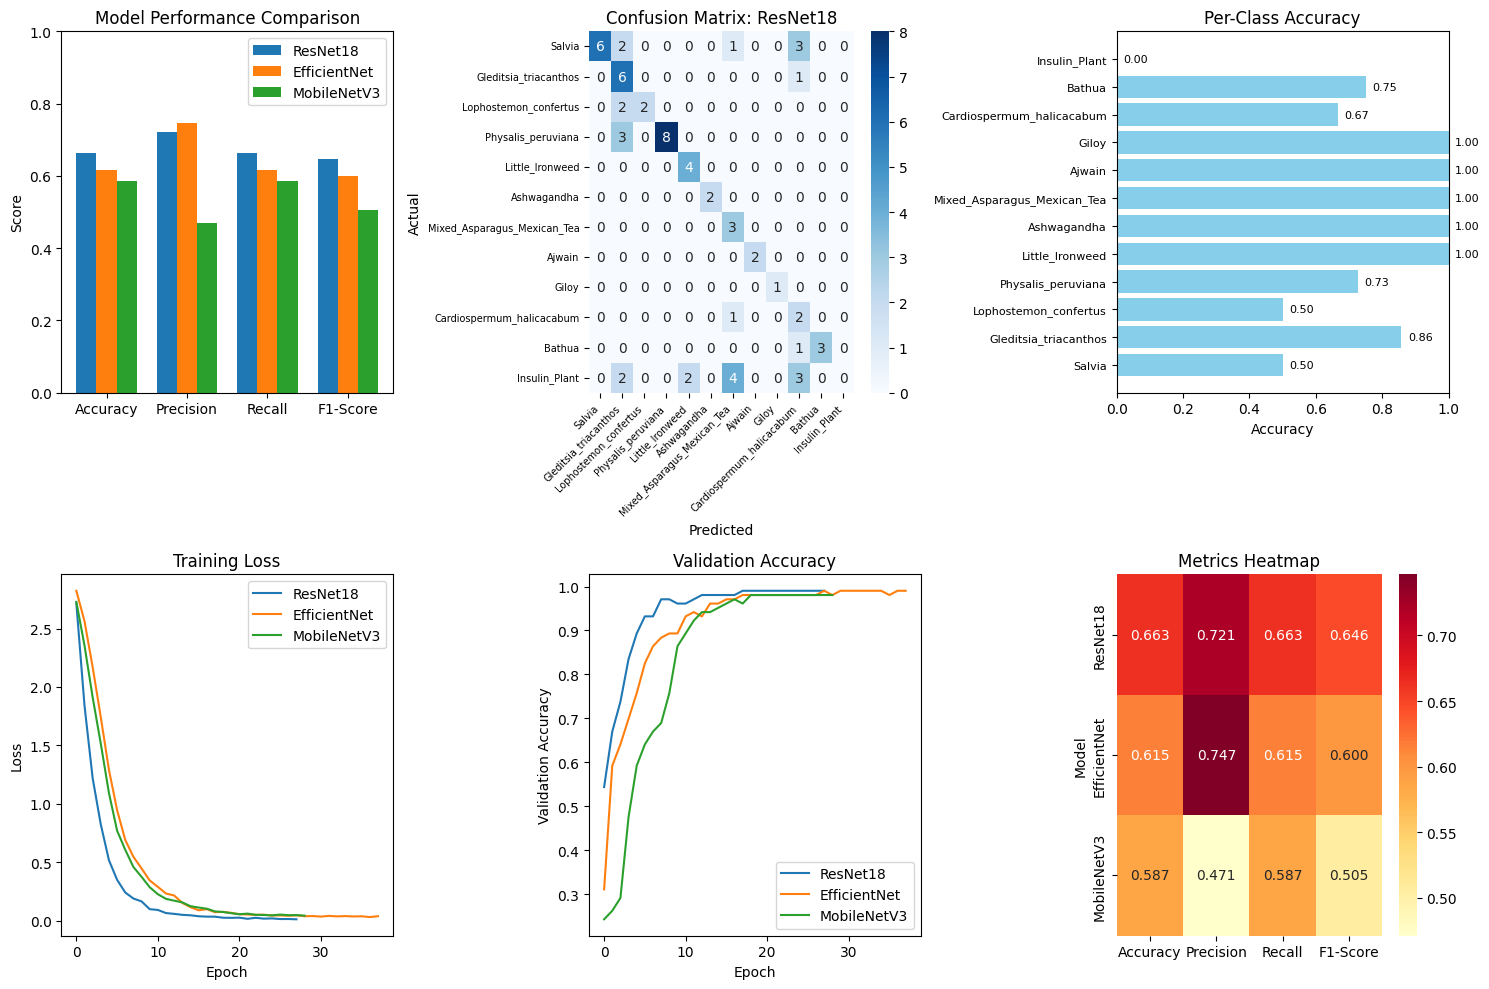

In [20]:
# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

#  Bar chart comparison
ax1 = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25
for i, r in enumerate(results):
    values = [r['accuracy'], r['precision'], r['recall'], r['f1_score']]
    ax1.bar(x + i*width, values, width, label=r['model'])
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim(0, 1)

#  Confusion Matrix - Best Model
ax2 = axes[0, 1]
best_res = [r for r in results if r['model'] == best['Model']][0]
cm = confusion_matrix(best_res['true_labels'], best_res['predictions'])

# Get unique labels present in test set
unique_labels = np.unique(best_res['true_labels'])
# Filter cm to only rows/cols that exist
max_label = max(unique_labels)
if max_label >= cm.shape[0]:
    pad_size = max_label + 1 - cm.shape[0]
    cm = np.pad(cm, ((0, pad_size), (0, pad_size)), 'constant')

cm_filtered = cm[unique_labels][:, unique_labels]

# Get species names only for labels that exist
species_filtered = [test_species_names[i] for i in unique_labels if i < len(test_species_names)]

# Ensure cm_filtered and species_filtered have same length
min_len = min(cm_filtered.shape[0], len(species_filtered))
cm_filtered = cm_filtered[:min_len, :min_len]
species_filtered = species_filtered[:min_len]

sns.heatmap(cm_filtered, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=species_filtered, yticklabels=species_filtered)
ax2.set_title(f'Confusion Matrix: {best["Model"]}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)
plt.setp(ax2.yaxis.get_majorticklabels(), fontsize=7)

# Per-class accuracy
ax3 = axes[0, 2]
class_acc = cm_filtered.diagonal() / (cm_filtered.sum(axis=1) + 1e-8)

# Create bars with matching lengths
y_pos = np.arange(len(class_acc))
bars = ax3.barh(y_pos, class_acc, color='skyblue')
ax3.set_yticks(y_pos)
ax3.set_yticklabels(species_filtered, fontsize=8)
ax3.set_xlabel('Accuracy')
ax3.set_title('Per-Class Accuracy')
ax3.set_xlim(0, 1)
for i, (bar, acc) in enumerate(zip(bars, class_acc)):
    ax3.text(acc + 0.02, i, f'{acc:.2f}', va='center', fontsize=8)

# Training Curves
ax4 = axes[1, 0]
if 'train_losses1' in dir() and len(train_losses1) > 0: 
    ax4.plot(train_losses1, label='ResNet18')
if 'train_losses2' in dir() and len(train_losses2) > 0: 
    ax4.plot(train_losses2, label='EfficientNet')
if 'train_losses3' in dir() and len(train_losses3) > 0: 
    ax4.plot(train_losses3, label='MobileNetV3')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Loss')
ax4.set_title('Training Loss')
ax4.legend()

# Validation Curves
ax5 = axes[1, 1]
if 'val_accs1' in dir() and len(val_accs1) > 0: 
    ax5.plot(val_accs1, label='ResNet18')
if 'val_accs2' in dir() and len(val_accs2) > 0: 
    ax5.plot(val_accs2, label='EfficientNet')
if 'val_accs3' in dir() and len(val_accs3) > 0: 
    ax5.plot(val_accs3, label='MobileNetV3')
ax5.set_xlabel('Epoch')
ax5.set_ylabel('Validation Accuracy')
ax5.set_title('Validation Accuracy')
ax5.legend()

# Metrics Heatmap
ax6 = axes[1, 2]
metrics_data = df_results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
sns.heatmap(metrics_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax6)
ax6.set_title('Metrics Heatmap')

plt.tight_layout()
plt.show()

In [24]:
#  Saving Best Model
print("SAVING BEST MODEL")

# Get best model object
best_model_obj = None
best_path = None

if best['Model'] == 'ResNet18':
    best_model_obj = model1
    best_path = 'best_resnet18_finetuned.pth'
elif best['Model'] == 'EfficientNet':
    best_model_obj = model2
    best_path = 'best_efficientnet_finetuned.pth'
else:
    best_model_obj = model3
    best_path = 'best_mobilenet_finetuned.pth'

# Load best weights
best_model_obj.load_state_dict(torch.load(best_path))
best_model_obj.eval()

# Save with metadata
torch.save({
    'model_state_dict': best_model_obj.state_dict(),
    'model_name': best['Model'],
    'test_accuracy': float(best['Accuracy']),
    'test_precision': float(best['Precision']),
    'test_recall': float(best['Recall']),
    'test_f1': float(best['F1-Score']),
    'num_classes': num_classes,
    'species_mapping': {i: s for i, s in enumerate(source_df['species'].unique())},
    'class_names': list(source_df['species'].unique())
}, 'final_best_herbal_model.pth')

print(f" Model saved: final_best_herbal_model.pth")
print(f"   Model: {best['Model']}")
print(f"   Test Accuracy: {best['Accuracy']:.4f} ({best['Accuracy']*100:.2f}%)")

SAVING BEST MODEL
 Model saved: final_best_herbal_model.pth
   Model: ResNet18
   Test Accuracy: 0.6635 (66.35%)
